In [29]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
# imports

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler
from scipy.stats import norm
import time
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

In [46]:
df = pd.read_csv('/content/drive/MyDrive/bigdata/creditcard.csv')
full_df = df

In [32]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [33]:
print(f"{(df.loc[df['Class'] == 0].count().sum() / df.count().sum() * 100):.2f}")
print(f"{(df.loc[df['Class'] == 1].count().sum() / df.count().sum() * 100):.2f}")

99.83
0.17


In [34]:
df.isnull().sum().max()

0

/tmp/ipython-input-1787710332.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=colors)


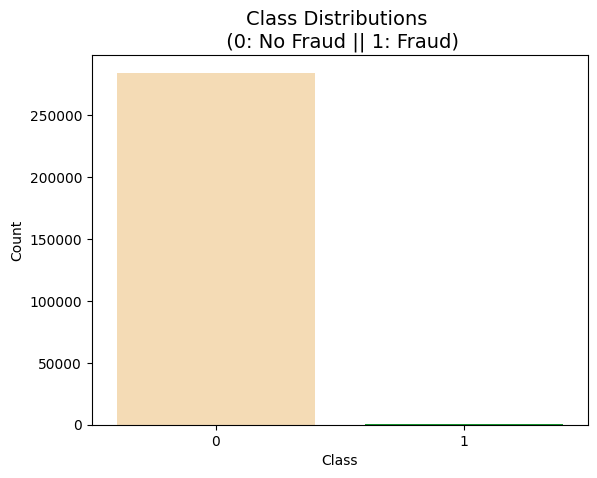

In [35]:
colors = ["#FFDDAA", "#00AC21"]

sns.countplot(x='Class', data=df, palette=colors)

plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)
plt.xlabel('Class')
plt.ylabel('Count')

plt.show()

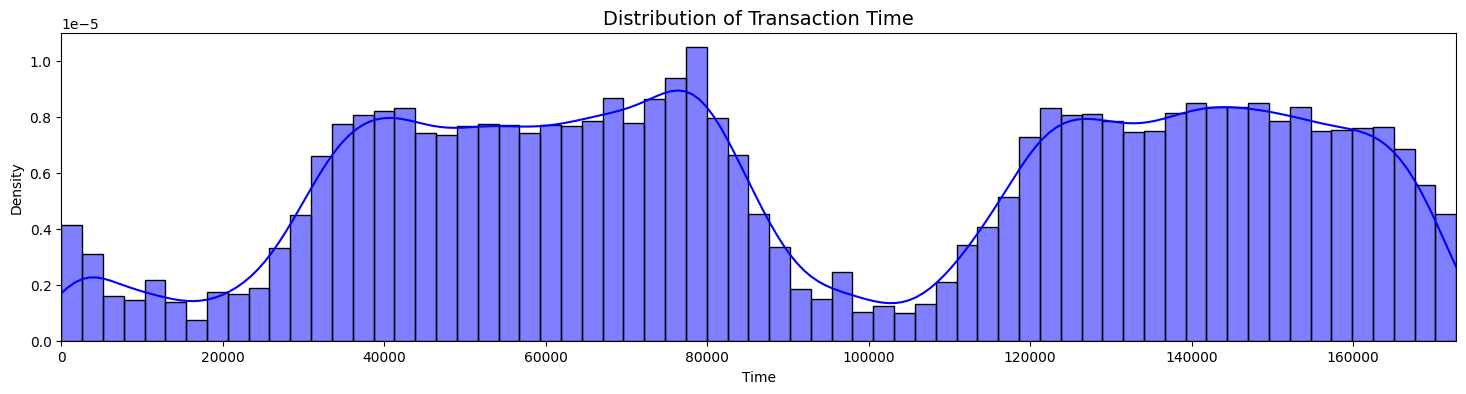

In [36]:
time_val = df['Time'].values

fig, ax1 = plt.subplots(1, 1, figsize=(18, 4))

sns.histplot(time_val, ax=ax1, color='b', kde=True, stat='density')

ax1.set_title('Distribution of Transaction Time', fontsize=14)
ax1.set_xlim([min(time_val), max(time_val)])
ax1.set_xlabel('Time')
ax1.set_ylabel('Density')

plt.show()

/tmp/ipython-input-441049621.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(amount_val, ax=ax1, color='r')


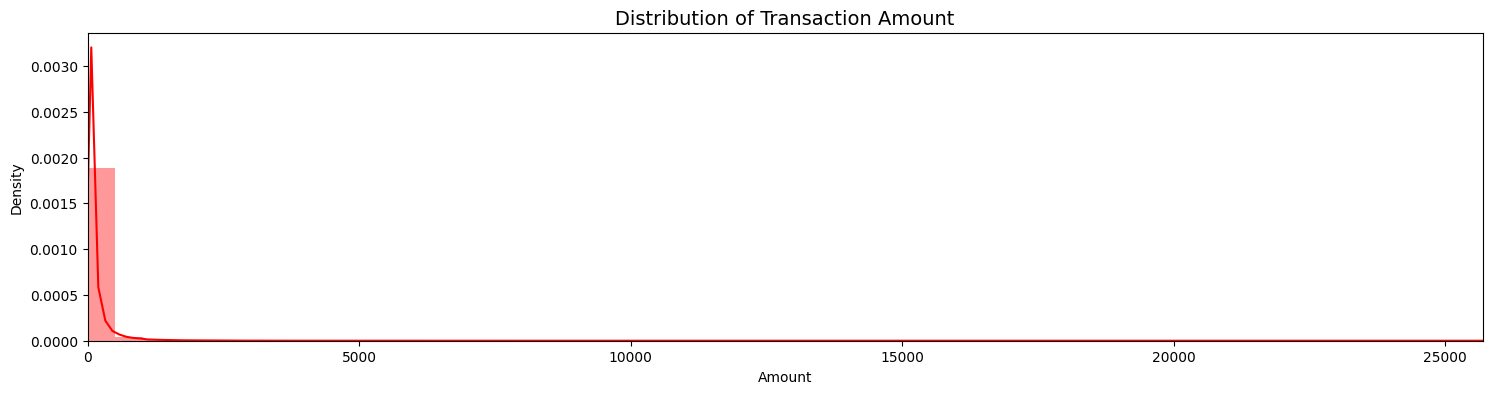

In [37]:
fig, ax1 = plt.subplots(1, 1, figsize=(18, 4))

amount_val = df['Amount'].values
sns.distplot(amount_val, ax=ax1, color='r')
ax1.set_title('Distribution of Transaction Amount', fontsize=14)
ax1.set_xlim([min(amount_val), max(amount_val)])
ax1.set_xlabel('Amount')
ax1.set_ylabel('Density')

plt.show()

In [38]:
std_scaler = StandardScaler()
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

In [39]:
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']

df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

# Amount and Time are Scaled!

df.head(10)

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0
5,-0.256131,-0.994960,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,...,0.084968,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,0
6,-0.237686,-0.994937,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,...,-0.219633,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,0
7,0.262698,-0.994901,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,...,-0.156742,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,0
8,0.994900,-0.994901,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,...,0.052736,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,0
9,-0.255991,-0.994878,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,...,0.203711,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,0


In [40]:


# Since our classes are highly skewed we should make them equivalent in order to have a normal distribution of the classes.

# Lets shuffle the data before creating the subsamples

df = df.sample(frac=1)

# amount of fraud classes 492 rows.
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:492]

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

# Shuffle dataframe rows
new_df = normal_distributed_df.sample(frac=1, random_state=42)

new_df.head()



,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
199192,0.251520,0.565761,1.929174,-0.444726,-0.548830,0.247247,-0.490917,-0.320909,-0.504435,0.052405,...,-0.194347,-0.118482,-0.363773,0.368821,0.590959,-0.399452,-0.961466,0.043861,-0.016194,0
150680,1.146231,0.107931,-12.833631,7.508790,-20.491952,7.465780,-11.575304,-5.140999,-14.020564,8.332120,...,-1.378923,2.966842,0.615344,-0.766495,0.431261,-0.104975,-0.010091,-2.400811,-0.720557,1
175887,0.974638,0.444613,0.081023,-0.289960,-0.305833,-1.569312,0.485501,1.033969,0.036539,0.403392,...,0.189072,0.378911,1.057585,0.236862,-1.512275,-0.943461,-0.158435,0.170625,0.114947,0
219892,-0.296793,0.672388,0.120301,1.974141,-0.434087,5.390793,1.289684,0.280590,0.221963,0.067827,...,0.205691,-0.038690,0.204554,-0.167313,0.791547,-0.223675,0.473223,-0.160202,0.065039,1
57470,-0.296793,-0.431972,0.364377,1.443523,-2.220907,2.036985,-1.237055,-1.728161,-2.058582,0.358895,...,0.310980,0.402730,-0.132129,-0.032977,0.460861,0.560404,0.409366,0.539668,0.296918,1


Distribution of the Classes in the subsample dataset
Class
0    0.5
1    0.5
Name: count, dtype: float64


/tmp/ipython-input-1331179676.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=new_df, palette=colors)


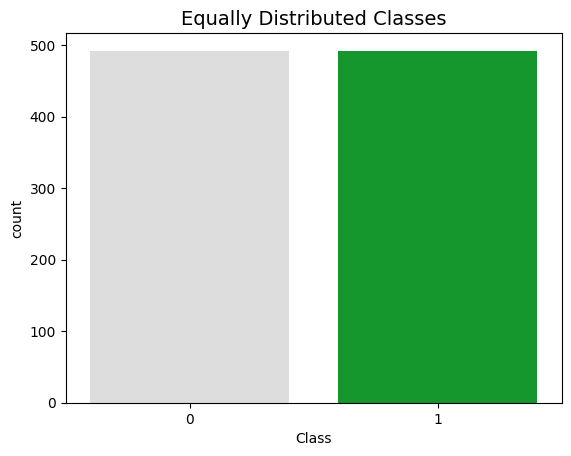

In [41]:
colors = ["#DDDDDD", "#00AC21"]

print('Distribution of the Classes in the subsample dataset')
# This prints the proportions (e.g., 0.5 for non-fraud, 0.5 for fraud)
print(new_df['Class'].value_counts()/len(new_df))


# CORRECTION: Explicitly use the 'x' argument for clarity and compatibility
sns.countplot(x='Class', data=new_df, palette=colors)

plt.title('Equally Distributed Classes', fontsize=14)
plt.show()

/tmp/ipython-input-4279679877.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(v14_fraud_dist,ax=ax1, fit=norm, color='#FB8861')
/tmp/ipython-input-4279679877.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(v12_fraud_dist,ax=ax2, fit=norm, color='#56F9BB')
/tmp/ipython-input-4279679877.py

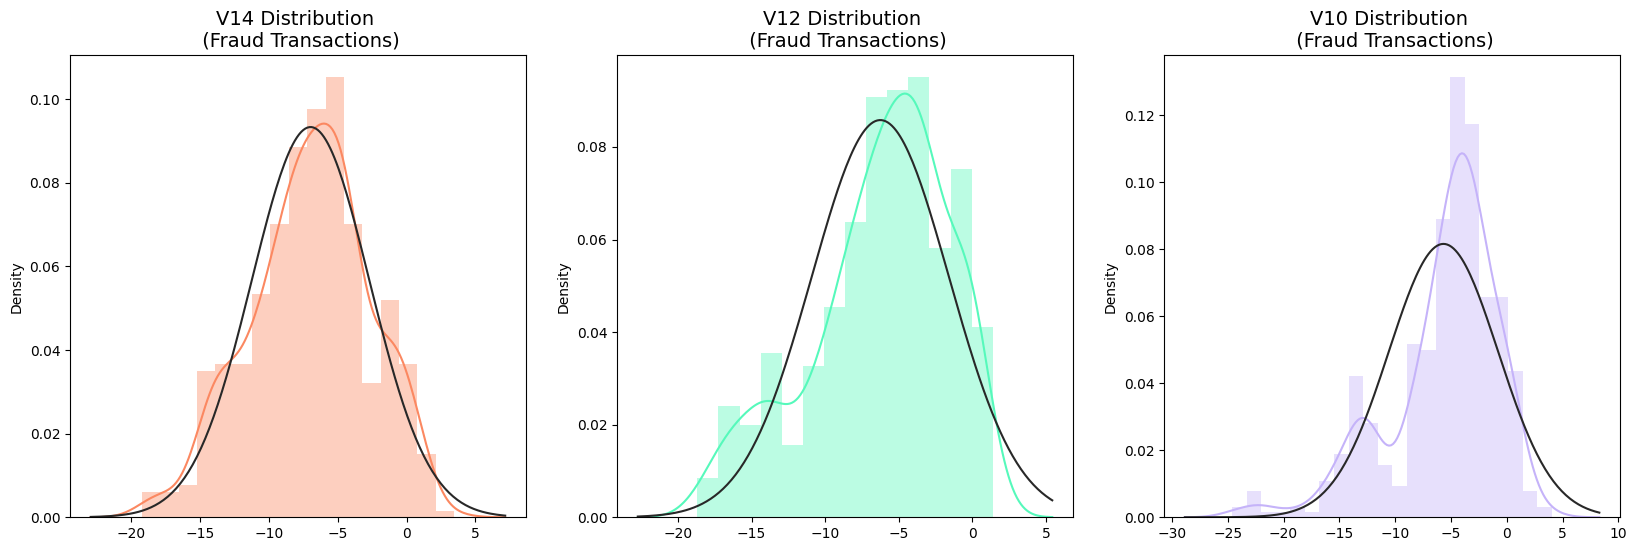

In [42]:
f, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20, 6))

v14_fraud_dist = new_df['V14'].loc[new_df['Class'] == 1].values
sns.distplot(v14_fraud_dist,ax=ax1, fit=norm, color='#FB8861')
ax1.set_title('V14 Distribution \n (Fraud Transactions)', fontsize=14)

v12_fraud_dist = new_df['V12'].loc[new_df['Class'] == 1].values
sns.distplot(v12_fraud_dist,ax=ax2, fit=norm, color='#56F9BB')
ax2.set_title('V12 Distribution \n (Fraud Transactions)', fontsize=14)


v10_fraud_dist = new_df['V10'].loc[new_df['Class'] == 1].values
sns.distplot(v10_fraud_dist,ax=ax3, fit=norm, color='#C5B3F9')
ax3.set_title('V10 Distribution \n (Fraud Transactions)', fontsize=14)

plt.show()

In [43]:
# Assuming 'new_df' is already defined and loaded
X = new_df.drop('Class', axis=1)
y = new_df['Class']


# T-SNE Implementation
t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X)
t1 = time.time()
print("T-SNE took {:.2} s".format(t1 - t0))

# PCA Implementation
t0 = time.time()
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X)
t1 = time.time()
print("PCA took {:.2} s".format(t1 - t0))

# TruncatedSVD
t0 = time.time()
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X)
t1 = time.time()
print("Truncated SVD took {:.2} s".format(t1 - t0))

T-SNE took 8.4 s
PCA took 0.0029 s
Truncated SVD took 0.032 s


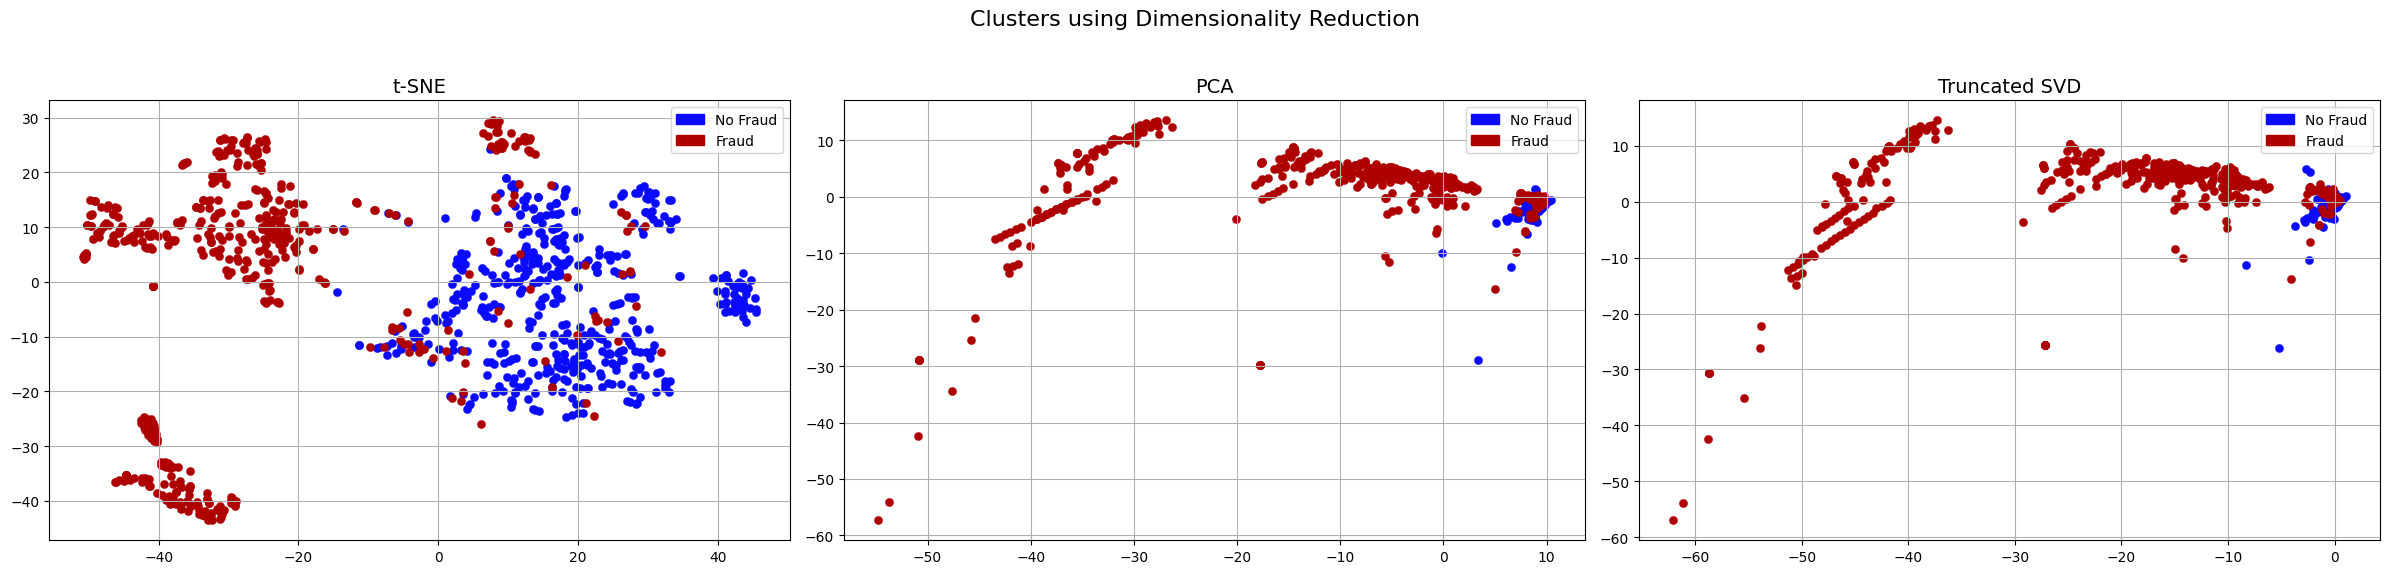

In [44]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,6))
f.suptitle('Clusters using Dimensionality Reduction', fontsize=16) # Increased fontsize for clarity

# Define custom patches for the legend
blue_patch = mpatches.Patch(color='#0A0AFF', label='No Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')


# --- t-SNE scatter plot (ax1) ---
# CORRECTION 2: Use fixed colors and filter data for cleaner visualization
ax1.scatter(X_reduced_tsne[y == 0, 0], X_reduced_tsne[y == 0, 1], c='#0A0AFF', linewidths=0.2)
ax1.scatter(X_reduced_tsne[y == 1, 0], X_reduced_tsne[y == 1, 1], c='#AF0000', linewidths=0.2)
ax1.set_title('t-SNE', fontsize=14)
ax1.grid(True)
ax1.legend(handles=[blue_patch, red_patch])


# --- PCA scatter plot (ax2) ---
# Filter data for non-fraud (y == 0) and fraud (y == 1)
ax2.scatter(X_reduced_pca[y == 0, 0], X_reduced_pca[y == 0, 1], c='#0A0AFF', linewidths=0.2)
ax2.scatter(X_reduced_pca[y == 1, 0], X_reduced_pca[y == 1, 1], c='#AF0000', linewidths=0.2)
ax2.set_title('PCA', fontsize=14)
ax2.grid(True)
ax2.legend(handles=[blue_patch, red_patch])


# --- TruncatedSVD scatter plot (ax3) ---
# Filter data for non-fraud (y == 0) and fraud (y == 1)
ax3.scatter(X_reduced_svd[y == 0, 0], X_reduced_svd[y == 0, 1], c='#0A0AFF', linewidths=0.2)
ax3.scatter(X_reduced_svd[y == 1, 0], X_reduced_svd[y == 1, 1], c='#AF0000', linewidths=0.2)
ax3.set_title('Truncated SVD', fontsize=14)
ax3.grid(True)
ax3.legend(handles=[blue_patch, red_patch])

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

In [47]:
df_timesorted = full_df.sort_values("Time").reset_index(drop=True)

# Our binary series: 0 = no fraud, 1 = fraud
y = df_timesorted["Class"].astype(int)

def create_lagged_features(series, max_lag=10):
    data = {}
    for lag in range(1, max_lag + 1):
        data[f"lag_{lag}"] = series.shift(lag)

    X = pd.DataFrame(data)
    target = series.copy()

    X = X.iloc[max_lag:].reset_index(drop=True)
    target = target.iloc[max_lag:].reset_index(drop=True)
    return X, target

p = 10  # AR order
X, y_ar = create_lagged_features(y, max_lag=p)

print("Shape of X:", X.shape)
print("Fraud rate:", y_ar.mean())

Shape of X: (284797, 10)
Fraud rate: 0.001727546287355555


In [48]:
split_ratio = 0.8
split_idx = int(len(X) * split_ratio)

X_train = X.iloc[:split_idx]
y_train = y_ar.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_test  = y_ar.iloc[split_idx:]

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 227837
Test size: 56960


In [49]:
clf = LogisticRegression(class_weight="balanced", max_iter=1000)
clf.fit(X_train, y_train)

# Predictions
y_proba = clf.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print("ROC AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred, digits=4))

ROC AUC: 0.49626638539743934
              precision    recall  f1-score   support

           0     0.9987    0.9898    0.9942     56885
           1     0.0034    0.0267    0.0061        75

    accuracy                         0.9885     56960
   macro avg     0.5011    0.5082    0.5001     56960
weighted avg     0.9974    0.9885    0.9929     56960



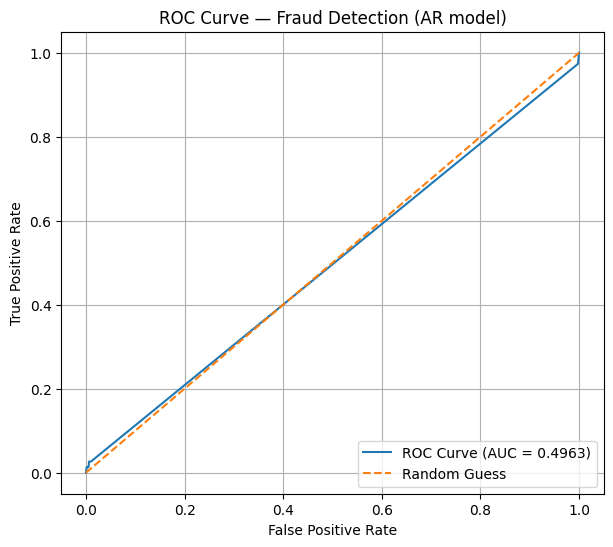

In [50]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Compute ROC AUC score
roc_auc = roc_auc_score(y_test, y_proba)

# ----- Plot -----
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Fraud Detection (AR model)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [51]:
X = new_df.drop("Class", axis=1)
y = new_df["Class"].astype(int)

# Stratified split because the dataset is extremely imbalanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Fraud rate train:", y_train.mean())
print("Fraud rate test :", y_test.mean())

Fraud rate train: 0.5006353240152478
Fraud rate test : 0.49746192893401014


In [52]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    class_weight="balanced_subsample",  # handle imbalance
    random_state=42
)

rf.fit(X_train, y_train)

# Probabilities for ROC AUC
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred  = (rf_proba >= 0.5).astype(int)

print("=== RandomForest ===")
print("ROC AUC:", roc_auc_score(y_test, rf_proba))
print(classification_report(y_test, rf_pred, digits=4))

=== RandomForest ===
ROC AUC: 0.9721706864564007
              precision    recall  f1-score   support

           0     0.8942    0.9394    0.9163        99
           1     0.9355    0.8878    0.9110        98

    accuracy                         0.9137       197
   macro avg     0.9149    0.9136    0.9136       197
weighted avg     0.9148    0.9137    0.9136       197



In [53]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",  # good default, works on CPU
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_pred  = (xgb_proba >= 0.5).astype(int)

print("\n=== XGBoost ===")
print("ROC AUC:", roc_auc_score(y_test, xgb_proba))
print(classification_report(y_test, xgb_pred, digits=4))

scale_pos_weight: 0.9974619289340102

=== XGBoost ===
ROC AUC: 0.9819624819624819
              precision    recall  f1-score   support

           0     0.9208    0.9394    0.9300        99
           1     0.9375    0.9184    0.9278        98

    accuracy                         0.9289       197
   macro avg     0.9291    0.9289    0.9289       197
weighted avg     0.9291    0.9289    0.9289       197



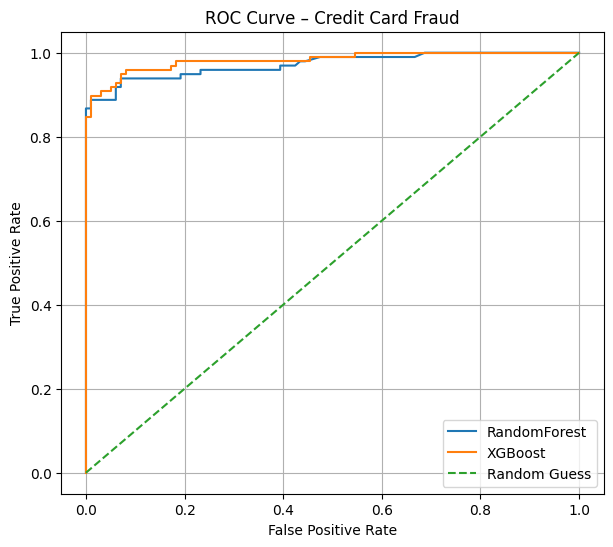

In [54]:
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
# XGB ROC
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)

plt.figure(figsize=(7, 6))
plt.plot(rf_fpr,  rf_tpr,  label="RandomForest")
plt.plot(xgb_fpr, xgb_tpr, label="XGBoost")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Credit Card Fraud")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()